In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import joblib


In [2]:
file_path = '../data/consumer_complaints_sample_balanced.csv'
df = pd.read_csv(file_path)

print("✅ Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()


✅ Dataset loaded successfully.
Shape: (20000, 3)


,product,complaint_text,label
0,Consumer Loan,I reached an agreement with Universal Acceptan...,2
1,Credit reporting or other personal consumer re...,This is a formal complaint that Equifax is bei...,0
2,Debt collection,RECEIVABLE RECOVERY XXXX XXXX XXXX XXXX XXXX X...,1
3,Credit reporting or other personal consumer re...,I lodged a complaint with these Bureaus a mont...,0
4,Consumer Loan,Please see the attached document with the full...,2


In [3]:
X = df['complaint_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 16000
Testing samples: 4000


In [4]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("✅ TF-IDF features shape:", X_train_tfidf.shape)


✅ TF-IDF features shape: (16000, 5000)


In [5]:
def train_and_evaluate(model, model_name):
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    
    acc = accuracy_score(y_test, y_pred)
    print(f"\n🔹 {model_name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} – Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()
    
    return acc, model



🔹 Logistic Regression Accuracy: 0.8820
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1000
           1       0.83      0.82      0.83      1000
           2       0.89      0.88      0.89      1000
           3       0.94      0.94      0.94      1000

    accuracy                           0.88      4000
   macro avg       0.88      0.88      0.88      4000
weighted avg       0.88      0.88      0.88      4000



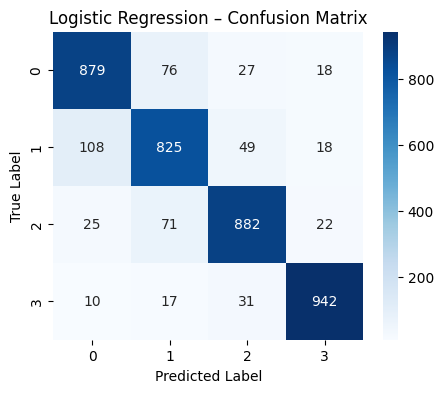


🔹 Naive Bayes Accuracy: 0.8455
              precision    recall  f1-score   support

           0       0.84      0.83      0.84      1000
           1       0.81      0.72      0.76      1000
           2       0.82      0.88      0.85      1000
           3       0.90      0.95      0.93      1000

    accuracy                           0.85      4000
   macro avg       0.84      0.85      0.84      4000
weighted avg       0.84      0.85      0.84      4000



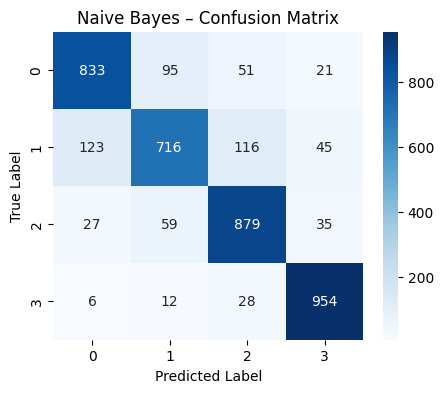


🔹 Random Forest Accuracy: 0.8620
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1000
           1       0.82      0.81      0.82      1000
           2       0.85      0.86      0.85      1000
           3       0.92      0.92      0.92      1000

    accuracy                           0.86      4000
   macro avg       0.86      0.86      0.86      4000
weighted avg       0.86      0.86      0.86      4000



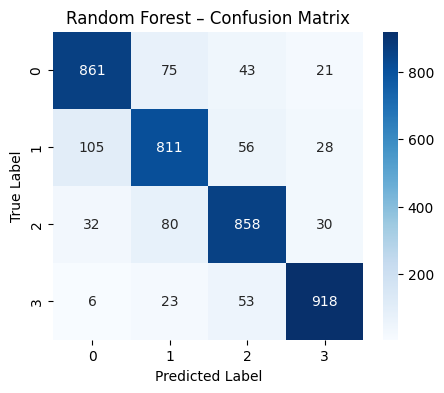

In [6]:
results = {}

# Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
acc_lr, model_lr = train_and_evaluate(log_reg, "Logistic Regression")
results["Logistic Regression"] = acc_lr

# Naive Bayes
nb = MultinomialNB()
acc_nb, model_nb = train_and_evaluate(nb, "Naive Bayes")
results["Naive Bayes"] = acc_nb

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
acc_rf, model_rf = train_and_evaluate(rf, "Random Forest")
results["Random Forest"] = acc_rf


                 Model  Accuracy
0  Logistic Regression    0.8820
2        Random Forest    0.8620
1          Naive Bayes    0.8455


c:\Users\chinm\OneDrive\Desktop\Desktop\project\Kaiburr\Chinmay\kaiburr-text-classification\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


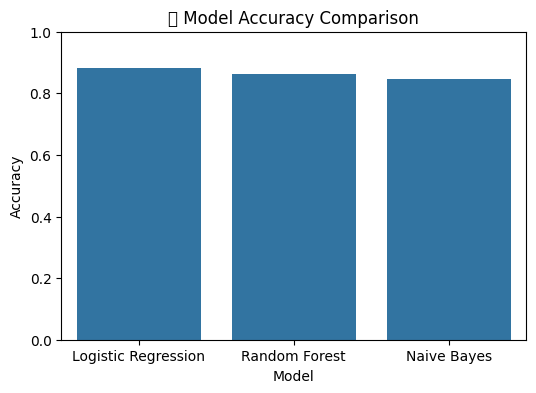

In [7]:
results_df = pd.DataFrame(list(results.items()), columns=['Model','Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)
print(results_df)

plt.figure(figsize=(6,4))
sns.barplot(x='Model', y='Accuracy', data=results_df)
plt.title("🏆 Model Accuracy Comparison")
plt.ylim(0,1)
plt.show()


In [9]:
best_model_name = results_df.iloc[0]['Model'] 
best_acc = results_df.iloc[0]['Accuracy']

print(f"✅ Best Model: {best_model_name} (Accuracy = {best_acc:.4f})")

# Choose correct model object
best_model = {
    "Logistic Regression": model_lr,
    "Naive Bayes": model_nb,
    "Random Forest": model_rf
}[best_model_name]

# Save vectorizer + model
joblib.dump(tfidf, '../model/tfidf_vectorizer.pkl')
joblib.dump(best_model, f"../model/{best_model_name.replace(' ', '_').lower()}_model.pkl")

print("💾 Model and vectorizer saved successfully in /model/")


✅ Best Model: Logistic Regression (Accuracy = 0.8820)
💾 Model and vectorizer saved successfully in /model/


In [10]:
sample_text = "I found incorrect information on my credit report and they refused to fix it."
sample_tfidf = tfidf.transform([sample_text])
prediction = best_model.predict(sample_tfidf)[0]

label_names = {
    0: 'Credit Reporting',
    1: 'Debt Collection',
    2: 'Consumer Loan',
    3: 'Mortgage'
}

print(f"🧠 Predicted Category: {label_names[prediction]}")


🧠 Predicted Category: Credit Reporting
